In [21]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

In [22]:
# Gerçek değerler (Doğa tarafından biliniyor, bizim tarafımızdan değil)
true_mu = 150.0 # Gerçek parlaklık
true_sigma = 10.0 # Gözlem hatası
n_obs = 50 # Gözlem sayısı

# Gürültülü veri oluşturma
np.random.seed(42)
data = true_mu + true_sigma * np.random.randn(n_obs)

In [23]:
# 1. Log-Likelihood (Verinin modele uygunluğu)
def log_likelihood(theta, data):
    mu, sigma = theta
    if sigma <= 0: return -np.inf # Fiziksel olmayan durum
    return -0.5 * np.sum(((data - mu) / sigma)**2 + np.log(2 * np.pi * sigma**2))

# 2. Log-Prior (Parametreler hakkındaki ön bilgilerimiz)
def log_prior(theta):
    mu, sigma = theta
    if 0 < mu < 300 and 0 < sigma < 50: # Geniş ve informatif olmayan bir sınır
        return 0.0
    return -np.inf

# 3. Log-Posterior (Hedef fonksiyonumuz)
def log_probability(theta, data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

In [24]:
# Başlangıç değerleri
initial = [140, 5]
n_walkers = 32
pos = initial + 1e-4 * np.random.randn(n_walkers, 2)
sampler = emcee.EnsembleSampler(n_walkers, 2, log_probability, args=(data,))
sampler.run_mcmc(pos, 2000, progress=True)

# Örnekleri toplama (ilk 500 adımı 'burn-in' olarak atıyoruz)
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

100%|██████████| 2000/2000 [00:00<00:00, 3251.71it/s]


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\serka\AppData\Local\Temp\ipykernel_10792\1558631152.py:2: SyntaxWarning: invalid escape sequence '\m'
  flat_samples, labels=["$\mu$ (Parlaklık)", "$\sigma$ (Hata)"],
C:\Users\serka\AppData\Local\Temp\ipykernel_10792\1558631152.py:2: SyntaxWarning: invalid escape sequence '\s'
  flat_samples, labels=["$\mu$ (Parlaklık)", "$\sigma$ (Hata)"],


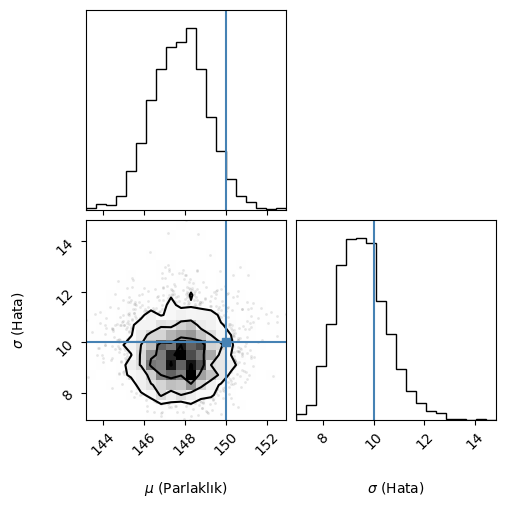

In [25]:
fig = corner.corner(
flat_samples, labels=["$\mu$ (Parlaklık)", "$\sigma$ (Hata)"],
truths=[true_mu, true_sigma]
)

plt.show()

In [27]:
# Tablo
mcmc_mu = np.percentile(flat_samples[:, 0], [16, 50, 84])
mcmc_sigma = np.percentile(flat_samples[:, 1], [16, 50, 84])
mu_err_minus, mu_err_plus = mcmc_mu[1] - mcmc_mu[0], mcmc_mu[2] - mcmc_mu[1]
sigma_err_minus, sigma_err_plus = mcmc_sigma[1] - mcmc_sigma[0], mcmc_sigma[2] - mcmc_sigma[1]

print(f"Tahmin Edilen Mu: {mcmc_mu[1]:.2f}")
print(f"Mu Alt Sınır: {mcmc_mu[0]:.2f}")
print(f"Mu Üst Sınır: {mcmc_mu[2]:.2f}")
print(f"Tahmin Edilen Sigma: {mcmc_sigma[1]:.2f}")
print(f"Sigma Alt Sınır - 16: {mcmc_sigma[0]:.2f}")
print(f"Sigma Üst Sınır - 84: {mcmc_sigma[2]:.2f}")

Tahmin Edilen Mu: 147.79
Mu Alt Sınır: 146.43
Mu Üst Sınır: 149.07
Tahmin Edilen Sigma: 9.49
Sigma Alt Sınır - 16: 8.55
Sigma Üst Sınır - 84: 10.53
